# McDonalds' Menu Analysis

<p align="center">
  <img src="McDs.png" alt="Centered Image" width=600 />
</p>

[Image source](https://medium.com/teachers-on-fire/when-your-child-recognizes-the-mcdonalds-sign-5297f53bdac4)


McDonalds is an American-based, international fast-food chain that has served meals & snacks to customers since the 1940's. Over time, their menu has grown to include a large variety of foods including burgers, beverages, breakfast foods, chicken, fish, coffee, salads, desserts, & more. They are one of the most well-known food chains in the world.

In the mid-1990's, the United States Food & Drug Administration (FDA) passed into the law the requirement for food packages to contain detailed information about a food item's nutrients, serving size, calories, & such. Consequentially, McDonalds' has provided various nutritional facts on their menus for each of their food items that they offer such as calories, carbohydrates, sodium, fat, etc. 
Such information can be explored to understand what McDonalds items are made of & how healthy they might be.


As a note, this project was done in early April.

# Project Objectives & Summary of Findings

With this data, this project aims to analyze the contents of different food items on the McDonalds menu. 
There were four key objectives that were analyzed in this project, each of which are listed below.
1) Find foods that exceed any recommended nutritional daily value.
2) Find the five food items with the most nutritional value across each nutritional element.
3) Inspect the typical value of each nutrient per category in the McDonalds menu.
4) Construct a daily meal plan that doesn't exceed the recommended daily nutritional values; i.e. breakfast, lunch, & dinner. Include at least eight unique food items. Assume that the daily nutritional values are for a 2,000 calorie (daily) diet.


-------------------------------------------------------------------------------------------------------------------------------


### Objective 1
**Find foods that exceed any recommended nutritional daily value.**

There are 21 unique food items on the McDonalds menu for which one or more daily recommended nutrition values are fully met &/or exceeded in a single serving. The nutrients whose daily values are met or exceeded consist of Total Fat, Saturated Fat, Cholesterol, Sodium, Vitamin A, & Vitamin C. 
There are only two food items that have nutritional values that exceed or meet the recommended daily values of more than one nutrient: Big Breakfast with Hotcakes (Large Biscuit), Chicken & Fish (exceeds three such daily values). 
Seven of these items are breakfast foods, six are salads, & four are beverages. No other category accounts for more than one item each.

For these items, if customers are looking to not exceed their daily nutrition for certain nutrients, they would be advised to avoid these foods or get them in smaller serving sizes.


------------------------------------------------------------------------------------------------------------------------------


### Objective 2
**Find the five food items with the most nutritional value across each nutrient.**

The 40 piece Chicken McNuggets has the most nutritional value for four different nutrients, more than any other food item on the McDonalds menu. Other items with significantly large values across multiple nutrients include: Big Breakfast with Hotcakes (Large & Regular Biscuits), Medium McFlurry w/M&M's Candies, Premium Southwest Salad with Crispy Chicken, Premium Southwest Salad with Gilled Chicken, Large Strawberry Shake, Large Chocolate Shake, & other Big Breakfast food items.


------------------------------------------------------------------------------------------------------------------------------


### Objective 3
**Inspect the typical value of each nutrient per category in the McDonalds menu.**

- McDonalds smoothies & shakes have the most nutritional value for five of 14 nutrients, which is the most of any category on the McDonalds menu. Beef & pork items have the most nutritional value for four nutrients.
- McDonalds beverages have the least nutritional value for 11 of 14 nutrients.


------------------------------------------------------------------------------------------------------------------------------


### Objective 4
**Construct a daily meal plan that doesn't exceed the recommended daily nutritional values; i.e. breakfast, lunch, & dinner. Include at least eight unique food items. Assume that the daily nutritional values are for a 2,000 calorie diet.**

Two approaches were used. The first involved a random sampling process to construct typical daily meal plans of McDonalds food items. In this case, ten such daily meal plans were constructed & analyzed as a whole. The second approach manually constructed a day's worth of McDonalds foods such that daily nutritional recommendations were not exceeded.

The following main conclusions were made:
- McDonalds meals usually fail to provide enough dietary fiber & iron relative to recommended daily nutrients.
- McDonalds meals often provide excessive amounts of calcium, calories, calories from fat, carbohydrates, protein, saturated fat, sodium, added sugars, & total fat.
- McDonalds meals sometimes provide too much cholesterol, trans fat, vitamin A, & vitamin C.

> Generally, a typical day's worth of McDonalds meals does not provide adequate amounts of nutritional value.

### Import packages

In [529]:
import numpy as np
import pandas as pd
import statistics
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go


The dataset for this project contains various nutritional information for about 250 unique products that have graced the McDonalds menu with their presence as of recently. Obtained from [Kaggle](https://www.kaggle.com/datasets/mcdonalds/nutrition-facts), this dataset has not been updated in at least eight years (2015), & so it is not the most representative of McDonalds' current food items. Of course, this data could be updated by referencing McDonalds' menu itself, but that could create a mostly new dataset & render the one obtained from Kaggle obsolete. Moreover, only adjusting parts of the old dataset with new data could make the resulting dataset inconsistent which would influence the credibility of results & conclusions from potential analyses.
As such, this dataset won't be updated by new data available elsewhere.


### Import & inspect data

In [530]:
#import data
orig_df = pd.read_csv('menu.csv')
#inspect data
display(orig_df.head(5))
display(orig_df.info())

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

None

In the original dataset, there are 260 rows & 24 columns. Each row corresponds to a unique McDonalds food item that was previously or is currently present on their menu. There are no missing values in the dataset.

Many of the nutritional columns do not display any corresponding units. It would be helpful to have these available, especially when presenting analyses to unfamiliar audiences. To determine these units, these products & their corresponding nutritional values could be searched for online. One source could be the [McDonalds' website](https://www.mcdonalds.com/us/en-us.html). The relevant nutrients have the following units:
- Grams (g): fat, carbohydrates, dietary fiber, added sugars, protein
- Milligrams (mg): cholesterol, sodium

----------------------------------------------------------------------------------------------------------------------

#### Daily Nutrition
There are several columns in the dataset that describe the quantity of some nutritional value in regards to a daily value, such as the 'Total Fat (% Daily Value)' column. It would be valuable to know McDonalds' assessment of these daily values to understand what kind of diet they might be basing their nutrition facts off of & if such a diet is healthy. For example, on McDonalds' current website, they state that the percentages of daily values (DV) are based on a 2,000 calorie diet, but this could vary in a plethora ways for the various other nutritional quantities (e.g. carbohydrates, protein, sodium, etc.).

For consistency purposes, it would be useful to get a detailed breakdown of a typical 2,000 calorie diet & what the recommended values are for the various different nutritional quantities. With such values, they could be valuable for analyses that may use this data to understand how different food items might make up a typical daily diet. For example, if someone had a typical meal at McDonalds, how much of their daily nutrition might be satisfied by such a meal?

To achieve this, the nutritional variables with associated daily percentage values could be used to calculate McDonalds' understanding of the recommended daily values for such quantities. Additionally, a second source, such as the [US Food & Drug Administration](https://www.fda.gov/food/nutrition-facts-label/daily-value-nutrition-and-supplement-facts-labels) (FDA), could help crosscheck these values & gain an understanding of McDonalds' typical daily nutritional values & how appropriate they may be.

In the McDonalds dataset, there are six nutrients that have both variables pertaining to an absolute quantity & a daily-value quantity including 'Total Fat,' 'Saturated Fat,' 'Cholesterol,' 'Sodium,' 'Carbohydrates,' & 'Dietary Fiber.' With these nutrients, the recommended daily values of these quantities, per McDonalds' standards, can be obtained & then compared to the current (2025) daily nutrient recommendations from the US FDA.

In [531]:
#Obtain recommended nutrient values for those available with the necessary data
#make a new dataset
df_recom_nutrients = orig_df.copy()

#get recommended TOTAL FAT from McD's data
df_recom_nutrients['REC Total Fat'] = df_recom_nutrients.apply(lambda x: 
                                x['Total Fat']*(100/x['Total Fat (% Daily Value)']) if x['Total Fat (% Daily Value)'] != 0 else np.nan, 
                                                               axis=1)
#SATURATED FAT
df_recom_nutrients['REC Saturated Fat'] = df_recom_nutrients.apply(lambda x: 
                                x['Saturated Fat']*(100/x['Saturated Fat (% Daily Value)']) if x['Saturated Fat (% Daily Value)'] != 0 else np.nan, 
                                                               axis=1)
#CHOLESTEROL
df_recom_nutrients['REC Cholesterol'] = df_recom_nutrients.apply(lambda x: 
                                x['Cholesterol']*(100/x['Cholesterol (% Daily Value)']) if x['Cholesterol (% Daily Value)'] != 0 else np.nan, 
                                                               axis=1)
#SODIUM
df_recom_nutrients['REC Sodium'] = df_recom_nutrients.apply(lambda x: 
                                x['Sodium']*(100/x['Sodium (% Daily Value)']) if x['Sodium (% Daily Value)'] != 0 else np.nan, 
                                                               axis=1)
#CARBOHYDRATES
df_recom_nutrients['REC Carbohydrates'] = df_recom_nutrients.apply(lambda x: 
                                x['Carbohydrates']*(100/x['Carbohydrates (% Daily Value)']) if x['Carbohydrates (% Daily Value)'] != 0 else np.nan, 
                                                               axis=1)
#DIETARY FIBER
df_recom_nutrients['REC Dietary Fiber'] = df_recom_nutrients.apply(lambda x: 
                                x['Dietary Fiber']*(100/x['Dietary Fiber (% Daily Value)']) if x['Dietary Fiber (% Daily Value)'] != 0 else np.nan, 
                                                               axis=1)
#select columns of interest
df_recom_nutrients = df_recom_nutrients[['Category','Item','REC Total Fat','REC Saturated Fat','REC Cholesterol',
                                         'REC Sodium','REC Carbohydrates','REC Dietary Fiber']]

In [532]:
#Want to compare McD's recommended daily values to the FDA's

#construct data from US FDA with recommended daily nutrients
FDA_daily_nutrients = pd.read_csv('FDA_daily_nuts.csv')
display(FDA_daily_nutrients[FDA_daily_nutrients.Nutrient.isin(['Cholesterol','Dietary Fiber','Total Fat','Sodium',
                                                               'Saturated Fat','Carbohydrates'])])
#get statistics of typical recommended nutrient values (McD's)
display(df_recom_nutrients[['REC Total Fat','REC Saturated Fat','REC Cholesterol','REC Sodium','REC Carbohydrates',
                    'REC Dietary Fiber']].describe().T)

,Nutrient,Current Daily Value
4,Carbohydrates,275g
6,Cholesterol,300mg
10,Dietary Fiber,28g
23,Saturated Fat,20g
25,Sodium,2300mg
28,Total Fat,78g


,count,mean,std,min,25%,50%,75%,max
REC Total Fat,211.0,64.758565,5.825869,50.000000,63.888889,64.705882,65.978723,100.0
REC Saturated Fat,200.0,20.077613,1.066996,16.666667,19.558971,20.000000,20.547945,25.0
REC Cholesterol,216.0,299.671356,39.622406,250.000000,285.714286,298.415186,307.036713,500.0
REC Sodium,240.0,2378.881805,228.492593,1000.000000,2333.333333,2398.412698,2428.571429,3500.0
REC Carbohydrates,244.0,301.071469,11.550181,266.666667,295.400433,300.000000,304.761905,400.0
REC Dietary Fiber,191.0,25.883058,6.102262,16.666667,22.222222,25.000000,28.571429,50.0


To compare each nutrient, the mean & median recommended (McDonalds) values were used.
- McDonalds' recommended **Total Fat** value is noticeably less than that of the US FDA's recommended value; ~ 65 vs 78g.
- McDonalds' recommended **Saturated Fat** value is essentially identical to that of the US FDA's recommended value; 20g.
- McDonalds' recommended **Cholesterol** value is about equal to that of the US FDA's recommended value; ~ 299 vs 300mg.
- McDonalds' recommended **Sodium** value is noticeably greater than that of the US FDA's recommended value; ~ 2390 vs 2300mg.
- McDonalds' recommended **Carbohydrates** value is noticeably greater than that of the US FDA's recommended value; ~ 300 vs 275g.
- McDonalds' recommended **Dietary Fiber** value is slightly less than that of the US FDA's recommended value; ~ 25 vs 28g.

From this information, the differences in the recommended daily values of nutrients per McDonalds' standards & those of the US FDA do not display consistent patterns overall. On the other hand, there are no gross differences in magnitude between these different recommended quantities, so the McDonalds' recommended daily nutrients can be described as acceptable for the purposes of these analyses. In other words, the daily nutritional values, as quantified by this McDonalds' dataset, do describe a relatively healthy daily diet.

# Analysis I
**Find foods that exceed any recommended nutritional daily value.**

Some columns in the dataset describe a nutritional value relative to a recommended daily value such as 'Total Fat (% Daily Value),' 'Saturated Fat (% Daily Value),' & others that contain the '(% Daily Value)' term. As an example, if some food item had a 'Total Fat (% Daily Value)' of 60, it implies that this food item, at the specified serving size, accounts for 60% of the recommended daily total fat intake for a typical diet.

If this daily value exceeded "100" percent, then the recommended daily amount for that nutrient has been exceeded which would inherently be unhealthy, at least according to McDonalds' recommendations.

In [533]:
#obtain columns that pertain to a daily value (DV) percentage
DV_cols = [col for col in orig_df.columns if re.search('% Daily Value', col)]

#find data points (food items) that exceed the recommended % DV of any nutrition
data_I = orig_df[orig_df[DV_cols].ge(100).any(axis=1)]
display(data_I.reset_index(drop=True).drop(columns=['Calories from Fat','Total Fat','Saturated Fat', 'Trans Fat',
                                        'Cholesterol','Sodium','Carbohydrates','Dietary Fiber','Sugars','Protein']))


,Category,Item,Serving Size,Calories,Total Fat (% Daily Value),Saturated Fat (% Daily Value),Cholesterol (% Daily Value),Sodium (% Daily Value),Carbohydrates (% Daily Value),Dietary Fiber (% Daily Value),Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Steak & Egg McMuffin,6.5 oz (185 g),430,36,46,100,40,10,18,15,2,30,20
1,Breakfast,Big Breakfast (Regular Biscuit),9.5 oz (269 g),740,73,87,185,65,17,12,15,2,15,25
2,Breakfast,Big Breakfast (Large Biscuit),10 oz (283 g),800,80,90,185,70,19,17,15,2,15,30
3,Breakfast,Big Breakfast with Hotcakes (Regular Biscuit),14.8 oz (420 g),1090,87,96,192,90,37,23,15,2,25,40
4,Breakfast,Big Breakfast with Hotcakes (Large Biscuit),15.3 oz (434 g),1150,93,100,192,94,39,28,15,2,30,40
5,Breakfast,Fruit & Maple Oatmeal,9.6 oz (251 g),290,6,8,2,7,19,19,2,130,10,10
6,Breakfast,Fruit & Maple Oatmeal without Brown Sugar,9.6 oz (251 g),260,6,8,2,5,16,22,2,130,6,10
7,Chicken & Fish,Chicken McNuggets (40 piece),22.8 oz (646 g),1880,182,101,89,150,39,24,0,15,8,25
8,Salads,Premium Bacon Ranch Salad (without Chicken),7.9 oz (223 g),140,11,18,9,13,3,12,170,30,15,6
9,Salads,Premium Bacon Ranch Salad with Crispy Chicken,9 oz (255 g),380,33,29,23,36,7,10,100,25,15,8


There are 21 unique food items on the McDonalds menu for which one or more daily recommended nutritional values are fully met &/or exceeded in a single serving. The nutrients whose daily values are met or exceeded consist of Total Fat, Saturated Fat, Cholesterol, Sodium, Vitamin A, & Vitamin C. 
There are only two food items that have nutritional values that exceed or meet the recommended daily values of more than one nutrient: Big Breakfast with Hotcakes (Large Biscuit), Chicken & Fish (exceeds three such daily values). 
Seven of these items are breakfast foods, six are salads, & four are beverages. No other category accounts for more than one item each.

For these items, if customers are looking to not exceed their daily nutrition for certain nutrients, they would be advised to avoid these foods or get them in smaller quantities.

# Analysis II
**Find the five food items with the most nutritional value across each nutrient.**

There are 15 unique nutritional elements in the dataset, but 'Calories from Fat' was not included here

C:\Users\elija\AppData\Local\Temp\ipykernel_6092\2828874159.py:70: UserWarning:

The figure layout has changed to tight



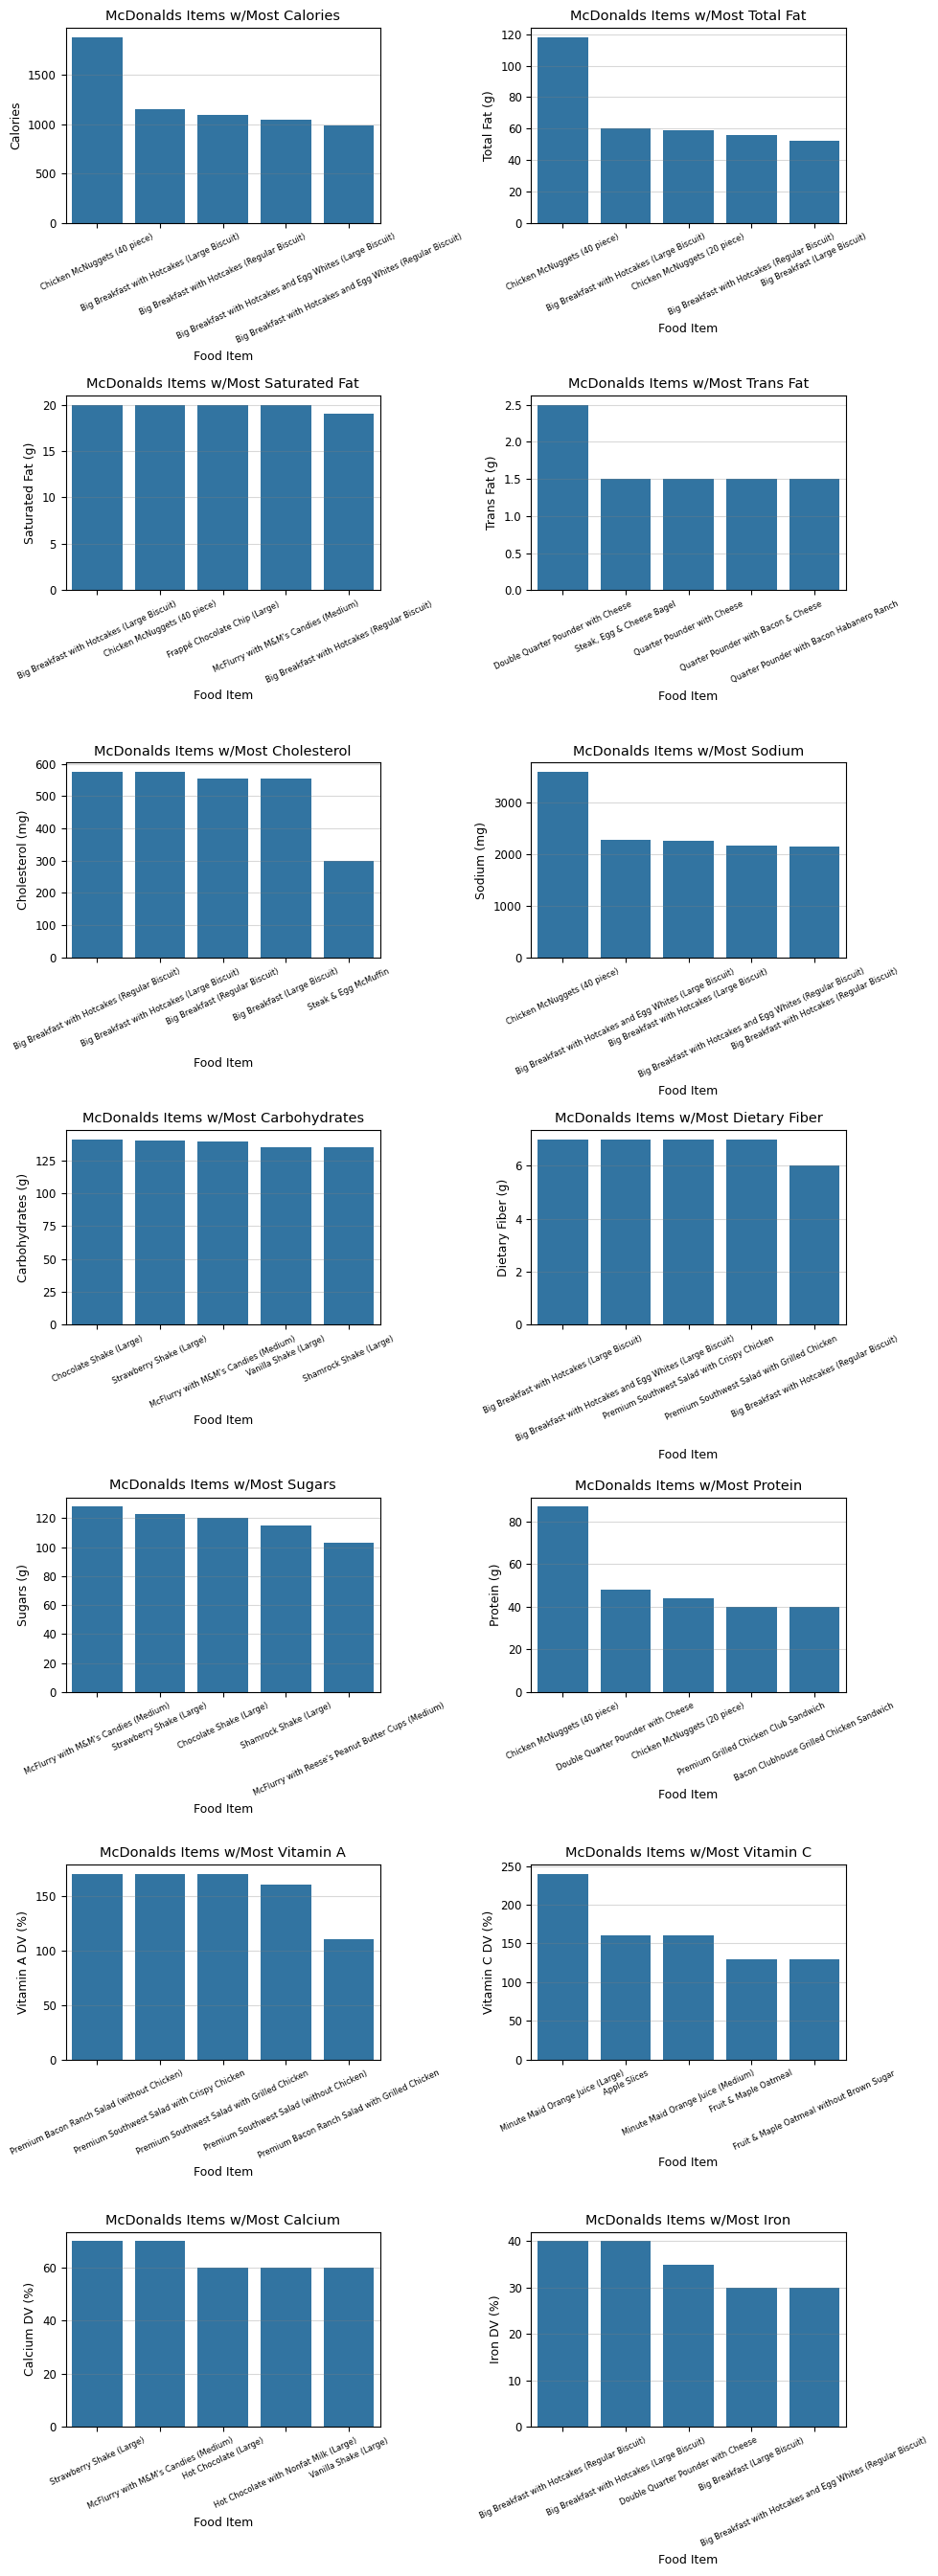

In [534]:
#Visualize five most nutritionally heavy foods for each nutrient element

fig, axes = plt.subplots(figsize=(10,27), ncols=2, nrows=7)

#CALORIES
ax1 = sns.barplot(data=orig_df.nlargest(5, 'Calories'), x='Item', y='Calories', color=sns.color_palette()[0],
                 ax=axes[0,0])
#TOTAL FAT
ax2 = sns.barplot(data=orig_df.nlargest(5, 'Total Fat'), x='Item', y='Total Fat', color=sns.color_palette()[0],
                 ax=axes[0,1])
#SATURATED FAT
ax3 = sns.barplot(data=orig_df.nlargest(5, 'Saturated Fat'), x='Item', y='Saturated Fat', color=sns.color_palette()[0],
                 ax=axes[1,0])
#TRANS FAT
ax4 = sns.barplot(data=orig_df.nlargest(5, 'Trans Fat'), x='Item', y='Trans Fat', color=sns.color_palette()[0],
                 ax=axes[1,1])
#CHOLESTEROL
ax5 = sns.barplot(data=orig_df.nlargest(5, 'Cholesterol'), x='Item', y='Cholesterol', color=sns.color_palette()[0],
                 ax=axes[2,0])
#SODIUM
ax6 = sns.barplot(data=orig_df.nlargest(5, 'Sodium'), x='Item', y='Sodium', color=sns.color_palette()[0],
                 ax=axes[2,1])
#CARBOHYDRATES
ax7 = sns.barplot(data=orig_df.nlargest(5, 'Carbohydrates'), x='Item', y='Carbohydrates', color=sns.color_palette()[0],
                 ax=axes[3,0])
#DIETARY FIBER
ax8 = sns.barplot(data=orig_df.nlargest(5, 'Dietary Fiber'), x='Item', y='Dietary Fiber', color=sns.color_palette()[0],
                 ax=axes[3,1])
#SUGARS
ax9 = sns.barplot(data=orig_df.nlargest(5, 'Sugars'), x='Item', y='Sugars', color=sns.color_palette()[0],
                 ax=axes[4,0])
#PROTEIN
ax10 = sns.barplot(data=orig_df.nlargest(5, 'Protein'), x='Item', y='Protein', color=sns.color_palette()[0],
                 ax=axes[4,1])
#VITAMIN A
ax11 = sns.barplot(data=orig_df.nlargest(5, 'Vitamin A (% Daily Value)'), x='Item', y='Vitamin A (% Daily Value)',
                   color=sns.color_palette()[0], ax=axes[5,0])
#VITAMIN C
ax12 = sns.barplot(data=orig_df.nlargest(5, 'Vitamin C (% Daily Value)'), x='Item', y='Vitamin C (% Daily Value)',
                   color=sns.color_palette()[0], ax=axes[5,1])
#CALCIUM
ax13 = sns.barplot(data=orig_df.nlargest(5, 'Calcium (% Daily Value)'), x='Item', y='Calcium (% Daily Value)',
                   color=sns.color_palette()[0], ax=axes[6,0])
#IRON
ax14 = sns.barplot(data=orig_df.nlargest(5, 'Iron (% Daily Value)'), x='Item', y='Iron (% Daily Value)',
                   color=sns.color_palette()[0], ax=axes[6,1])

#edit plot details
for k, v in {'McDonalds Items w/Most Calories':[0,0, 'Calories'],
            'McDonalds Items w/Most Total Fat':[0,1, 'Total Fat (g)'],
            'McDonalds Items w/Most Saturated Fat':[1,0, 'Saturated Fat (g)'],
            'McDonalds Items w/Most Trans Fat':[1,1, 'Trans Fat (g)'],
            'McDonalds Items w/Most Cholesterol':[2,0, 'Cholesterol (mg)'],
            'McDonalds Items w/Most Sodium':[2,1, 'Sodium (mg)'],
            'McDonalds Items w/Most Carbohydrates':[3,0, 'Carbohydrates (g)'],
            'McDonalds Items w/Most Dietary Fiber':[3,1, 'Dietary Fiber (g)'],
            'McDonalds Items w/Most Sugars':[4,0, 'Sugars (g)'],
            'McDonalds Items w/Most Protein':[4,1, 'Protein (g)'],
            'McDonalds Items w/Most Vitamin A':[5,0, 'Vitamin A DV (%)'],
            'McDonalds Items w/Most Vitamin C':[5,1, 'Vitamin C DV (%)'],
            'McDonalds Items w/Most Calcium':[6,0, 'Calcium DV (%)'],
            'McDonalds Items w/Most Iron':[6,1, 'Iron DV (%)']}.items():
    plt.sca(axes[v[0],v[1]])
    plt.title(k, fontsize=10.5)
    plt.xlabel('Food Item', fontsize=9)
    plt.xticks(fontsize=6, rotation=25)
    plt.ylabel(v[2], fontsize=9)
    plt.yticks(fontsize=8.5)
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();

The plots above display the food items on the McDonalds menu with the largest quantity of nutrition across each nutritional element in the dataset. Each plot contains the food items with the five most largest quantities of each respective nutrient. There are 260 unique food items in the dataset. Note that the vertical axes of each plot are unique & are unrelated to those of other plots. Additionally, the first ten plots represent absolute nutritional quantities whereas the bottom four plots display quantities with respect to McDonalds' daily nutritional recommendations.


#### Calories
- 40 piece Chicken McNuggets contains the most calories of any item on the McDonalds menu; 1,880. Note that 2,000 calories a day is a generally popular recommendation for nutritional advice, so this food item would account for nearly all of this daily allotment.

#### Total Fat
- 40 piece Chicken McNuggets contains the most fat of any item on the McDonalds menu; 118 grams (g). The (2025) daily recommendation of total fat, per the US FDA, is 78 g, so this food item would exceed this threshold significantly. This is the only food item on the menu that exceeds or meets this daily recommendation.

#### Saturated Fat
- There are four items on the McDonalds menu with the largest amount of saturated fat of all items: the Big Breakfast with Hotcakes (Large Biscuit), 40 piece Chicken McNuggets, Large Frappé Chocolate Chip, & Medium McFlurry with M&M's Candies all have 20 g of saturated fat each. The daily recommendation of saturated fat is 20 g, so each of these food items would meet this threshold in a single serving.

#### Trans Fat
- A Double Quarter Pounder with Cheese contains the most trans fat of any item on the McDonalds menu; 2.5 g. The daily recommendation of trans fat is to limit it to less than one percent of total energy intake. Given that this analysis is based off of a 2,000 calorie diet, this threshold would be about 2.2 g, indicating that a single serving of this food item would exceed this daily recommendation by a small margin. This is the only food item on the menu that exceeds or meets this daily recommendation.

#### Cholesterol
- There are two items on the McDonalds menu with the largest amount of cholesterol of all items: the Big Breakfast with Hotcakes (Regular Biscuit) & the Big Breakfast with Hotcakes (Large Biscuit) all have 575 milligrams (mg) of cholesterol each. The daily recommendation of cholesterol is 300 mg, so both of these food items would exceed this daily threshold significantly. Additionally, there are three other items on the menu that meet or exceed this daily recommendation: Big Breakfast (Regular Biscuit) & Big Breakfast (Large Biscuit) (555 mg), Steak & Egg McMuffin (300 mg).

#### Sodium
- 40 piece Chicken McNuggets contains the most sodium of any item on the McDonalds menu; 3,600 mg. The daily recommendation of sodium is 2,300 mg, so this food item would exceed this threshold significantly. This is the only food item on the menu that exceeds or meets this daily recommendation.

#### Carbohydrates
- A Large Chocolate Shake contains the most carbohydrates of any item on the McDonalds menu; 141 g. The daily reocmmendation of carbohydrates is 275 g, so this food item only contains about half of this quantity.

#### Dietary Fiber
- There are four items on the McDonalds menu with the largest amount of dietary fiber of all items: the Big Breakfast with Hotcakes (Large Biscuit), Big Breakfast with Hotcakes & Egg Whites (Large Biscuit), Premium Southwest Salad with Crispy Chicken, & Premium Southwest Salad with Gilled Chicken all have seven grams of dietary fiber each. The daily recommendation of dietary fiber is 28 g, so these foods only equate to a quarter of this daily quantity each.

#### Sugars
- A Medium McFlurry with M&M's Candies contains the most added sugars of any item on the McDonalds menu; 128 g. The daily recommendation of sugars is 50 g, so this food item would exceed this threshold by about 150%. In total, there are 63 items on the menu that meet or exceed this daily recommendation of 50 g of added sugars, most of which are either in the Coffee & Tea or Smoothies & Shakes category.

#### Protein
- 40 piece Chicken McNuggets contains the most protein of any item on the McDonalds menu; 87 g. The daily commendation of protein is 50 g, so this food item exceeds this quantity significantly. This is the only item that meets or exceeds this daily recommendation of protein.

#### Vitamin A
- There are three items on the McDonalds menu with the largest amount of Vitamin A as a percentage of daily value: the Premium Bacon Ranch Salad (without Chicken), Premium Southwest Salad with Crispy Chicken, & Premium Southwest Salad with Grilled Chicken all contain 170% of the recommended daily value of Vitamin A. In total, there are six items on the menu that exceed the recommended daily value of Vitamin A, all of which are salads. For reference, the daily recommendation of Vitamin A, per the US FDA, is 900 micrograms (mcg).

#### Vitamin C
- The Large Minute Maid Orange Juice contains the largest of Vitamin C as a percentage of daily value; 240%. In total, there are seven items on the menu that exceed the recommended daily value of Vitamin C, all of which include some fruit. Most of these items are beverages. For reference, the daily recommendation of Vitamin C is 90 mg.

#### Calcium
- There are two items on the McDonalds menu with the largest amount of Calcium as a percentage of daily value: the Large Strawberry Shake & Medium McFlurry with M&M's Candies both contain 70% of the recommended daily value of Calcium. For reference, the daily recommendation of Calcium is 1,300 mg.

#### Iron
- There are two items on the McDonalds menu with the largest amount of Iron as a percentage of daily value: the Big Breakfast with Hotcakes (Regular Biscuit) & Big Breakfast with Hotcakes (Large Biscuit) both contain 40% of the recommended daily value of Iron. For reference, the daily recommendation of Iron is 18 mg.

The 40 piece Chicken McNuggets has the most nutritional value for four different nutrients, more than any other food item on the McDonalds menu. Other items with significantly large values across multiple nutrients include: Big Breakfast with Hotcakes (Large & Regular Biscuits), Medium McFlurry w/M&M's Candies, Premium Southwest Salad with Crispy Chicken, Premium Southwest Salad with Gilled Chicken, Large Strawberry Shake, Large Chocolate Shake, & other Big Breakfast food items.

# Analysis III
**Inspect the typical value of each nutrient per category of the McDonalds menu.**

There are nine unique categories in the dataset, each of which accounts for between six (Salads) & 95 (Coffee & Tea) food items on the menu. 
For the typical values, calculate the mean & median values.

In [535]:
#indicate columns of interest
data_III_cols = ['Calories','Calories from Fat','Total Fat','Saturated Fat','Trans Fat','Cholesterol','Sodium',
                 'Carbohydrates','Dietary Fiber','Sugars','Protein','Vitamin A (% Daily Value)','Vitamin C (% Daily Value)',
                'Calcium (% Daily Value)','Iron (% Daily Value)']
#calculate avg nutrition per 'Category', round to 2 decimals
cat_means = orig_df.groupby('Category')[data_III_cols].mean().reset_index().round(2)
#indicate the statistic
cat_means['Metric'] = 'Average'

#calculate median nutrition per 'Category', round to 2 decimals
cat_meds = orig_df.groupby('Category')[data_III_cols].median().reset_index().round(2)
#indicate the statistic
cat_meds['Metric'] = 'Median'

#determine # unique food items each category accounts for
cat_counts = orig_df.Category.value_counts().reset_index()

#merge category means, medians, & counts together, sort
data_III = pd.concat([cat_means, cat_meds], axis=0).merge(cat_counts, on='Category').sort_values('Category').rename(
                columns={'count':'# items'}).reset_index(drop=True)

#reorganize columns
data_III = data_III[['Category','# items','Metric','Calories','Calories from Fat','Total Fat','Saturated Fat','Trans Fat',
                    'Cholesterol','Sodium','Carbohydrates','Dietary Fiber','Sugars','Protein','Vitamin A (% Daily Value)',
                     'Vitamin C (% Daily Value)','Calcium (% Daily Value)','Iron (% Daily Value)']]
data_III.head(4)

,Category,# items,Metric,Calories,Calories from Fat,Total Fat,Saturated Fat,Trans Fat,Cholesterol,Sodium,Carbohydrates,Dietary Fiber,Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Beef & Pork,15,Average,494.0,224.67,24.87,10.47,1.1,87.33,1020.67,40.13,2.53,8.80,27.33,6.93,7.33,23.00,23.33
1,Beef & Pork,15,Median,500.0,240.00,26.00,10.00,1.0,85.00,1030.00,41.00,3.00,9.00,24.00,6.00,2.00,25.00,20.00
2,Beverages,27,Average,113.7,0.74,0.09,0.06,0.0,0.56,41.48,28.81,0.04,27.85,1.33,0.74,23.48,2.96,0.30
3,Beverages,27,Median,100.0,0.00,0.00,0.00,0.0,0.00,30.00,27.00,0.00,27.00,0.00,0.00,0.00,0.00,0.00


C:\Users\elija\AppData\Local\Temp\ipykernel_6092\341982066.py:68: UserWarning:

The figure layout has changed to tight



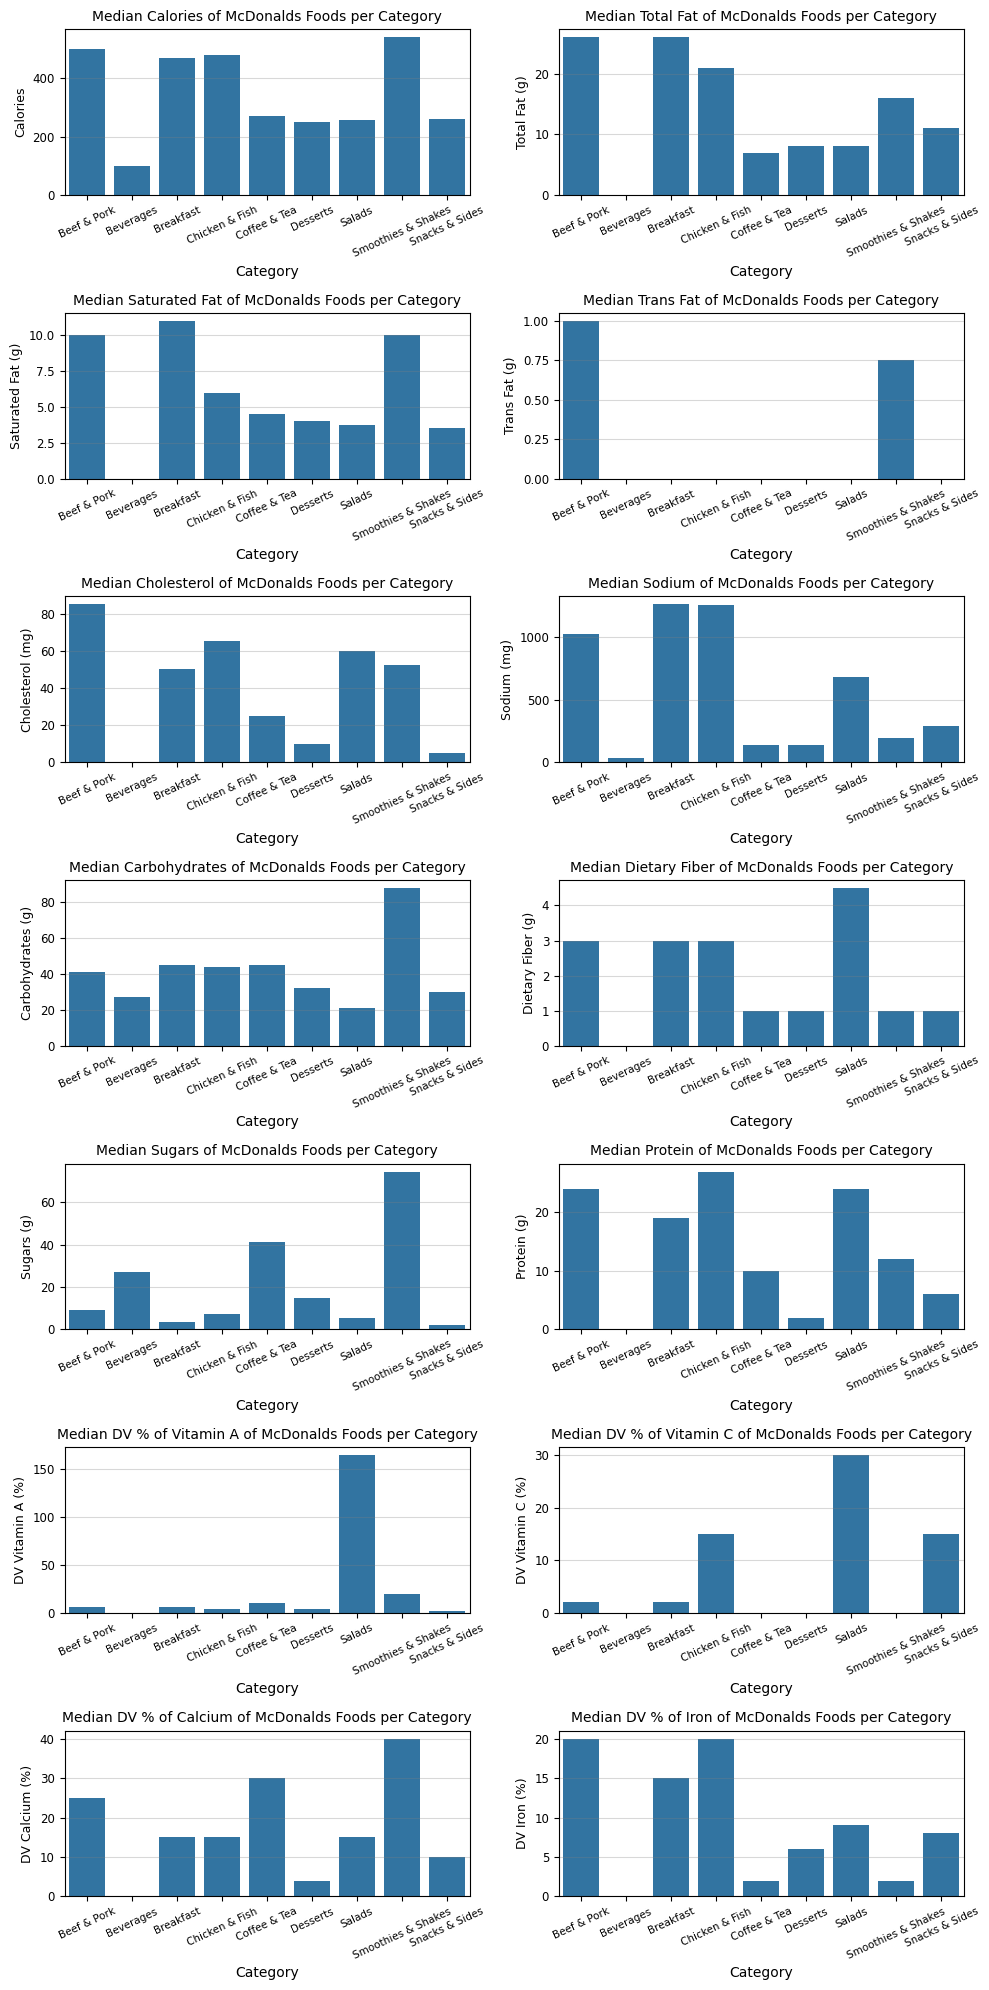

In [551]:
#Visualize these typical values, use the medians

fig, axes = plt.subplots(ncols=2, nrows=7, figsize=(10,20))
#CALORIES
ax1 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Calories', color=sns.color_palette()[0],
                 ax=axes[0,0])
#TOTAL FAT
ax2 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Total Fat', color=sns.color_palette()[0],
                 ax=axes[0,1])
#SATURATED FAT
ax3 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Saturated Fat', color=sns.color_palette()[0],
                 ax=axes[1,0])
#TRANS FAT
ax4 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Trans Fat', color=sns.color_palette()[0],
                 ax=axes[1,1])
#CHOLESTEROL
ax5 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Cholesterol', color=sns.color_palette()[0],
                 ax=axes[2,0])
#SODIUM
ax6 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Sodium', color=sns.color_palette()[0],
                 ax=axes[2,1])
#CARBOHYDRATES
ax7 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Carbohydrates', color=sns.color_palette()[0],
                 ax=axes[3,0])
#DIETARY FIBER
ax8 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Dietary Fiber', color=sns.color_palette()[0],
                 ax=axes[3,1])
#SUGARS
ax9 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Sugars', color=sns.color_palette()[0],
                 ax=axes[4,0])
#PROTEIN
ax10 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Protein', color=sns.color_palette()[0],
                 ax=axes[4,1])
#VITAMIN A (DV %)
ax11 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Vitamin A (% Daily Value)', 
                   color=sns.color_palette()[0], ax=axes[5,0])
#VITAMIN C (DV %)
ax12 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Vitamin C (% Daily Value)', 
                   color=sns.color_palette()[0], ax=axes[5,1])
#CALCIUM (DV %)
ax13 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Calcium (% Daily Value)', 
                  color=sns.color_palette()[0], ax=axes[6,0])
#IRON
ax14 = sns.barplot(data=data_III[data_III.Metric == 'Median'], x='Category', y='Iron (% Daily Value)', 
                   color=sns.color_palette()[0], ax=axes[6,1])

#edit plot details
for k, v in {'Median Calories of McDonalds Foods per Category':[0,0, 'Calories'],
             'Median Total Fat of McDonalds Foods per Category':[0,1, 'Total Fat (g)'],
            'Median Saturated Fat of McDonalds Foods per Category':[1,0, 'Saturated Fat (g)'],
             'Median Trans Fat of McDonalds Foods per Category':[1,1, 'Trans Fat (g)'],
             'Median Cholesterol of McDonalds Foods per Category':[2,0, 'Cholesterol (mg)'],
            'Median Sodium of McDonalds Foods per Category':[2,1, 'Sodium (mg)'],
             'Median Carbohydrates of McDonalds Foods per Category':[3,0, 'Carbohydrates (g)'],
            'Median Dietary Fiber of McDonalds Foods per Category':[3,1, 'Dietary Fiber (g)'],
            'Median Sugars of McDonalds Foods per Category':[4,0, 'Sugars (g)'],
             'Median Protein of McDonalds Foods per Category':[4,1, 'Protein (g)'],
             'Median DV % of Vitamin A of McDonalds Foods per Category':[5,0, 'DV Vitamin A (%)'],
             'Median DV % of Vitamin C of McDonalds Foods per Category':[5,1, 'DV Vitamin C (%)'],
            'Median DV % of Calcium of McDonalds Foods per Category':[6,0, 'DV Calcium (%)'],
            'Median DV % of Iron of McDonalds Foods per Category':[6,1, 'DV Iron (%)']}.items():
    plt.sca(axes[v[0],v[1]])
    plt.title(k, fontsize=10)
    plt.xticks(fontsize=7.5, rotation=25)
    plt.ylabel(v[2], fontsize=9)
    plt.yticks(fontsize=8.5)
    plt.grid(axis='y', alpha=0.3, color='gray')
    plt.tight_layout();

The plots above display some typical values of various nutritional elements of categories of foods on the McDonalds menu. In this case, these plots specifically illustrate the median values per category for all 15 of the nutrients in the dataset except 'Calories from Fat.' Recall that there are nine unique categories of food items in the dataset, each of which consist of somewhere between six & 95 unique items. Note that the vertical axis of each plots is different to that of the others.

On the US FDA's [website](https://www.fda.gov/food/nutrition-facts-label/daily-value-nutrition-and-supplement-facts-labels), they advise to choose foods that are:
- Higher in dietary fiber.
- Lower in saturated fat, sodium, & added sugars.

Additionally, when it comes to percentages of daily values, their general guide states:
- 5% DV or less of a nutrient per serving is considered low, whereas 20% DV or more is considered high.

#### Calories
- Typically, foods in the Smoothies & Shakes category of items on the McDonalds menu have the most calories of any of the nine categories; about 540 calories. Recall that a daily diet is recommended to consist of 2,000 calories. As such, a typical smoothy or shake from McDonalds would account for about a quarter of a person's daily calorie count.
- Typically, McDonalds beverages have the lowest number of calories of any of the nine categories; about 100 calories.

#### Total Fat
- Typically, foods in the Beef & Pork & Breakfast categories of items on the McDonalds menu have the most fat of the nine categories; about 26 grams (g) each. Recall that a daily diet is recommended to consist of 78 g of total fat. As such, a typical food item from either of these two categories would account for about a third of a person's daily total fat intake.
- Typically, McDonalds beverages have the lowest amount of total fat of any of the nine categories; about zero g.

#### Saturated Fat
- Typically, foods in the Breakfast category of items on the McDonalds menu have the most saturated fat of any of the nine categories; about 11 g. Recall that a daily diet is recommended to consist of 20 g of saturated fat. As such, a typical breakfast food from McDonalds would account for about half of a person's daily saturated fat intake. The US FDA might advise customers to avoid such items given their large quantities of saturated fat.
- Typically, McDonalds beverages have the lowest amount of saturated fat of any of the nine categories; about zero g.

#### Trans Fat
- Typically, only two categories of the nine in the dataset have items with any trans fat--Beef & Pork & Smoothies & Shakes--each of which typically have one gram or less of trans fat. Recall that a daily diet is recommended to limit trans fat to less than one percent of total energy intake. For a 2,000 calorie diet, this would equate to about 2.2 g.

#### Cholesterol
- Typically, foods in the Beef & Pork category of items on the McDonalds menu have the most cholesterol of any of the nine categories; about 85 milligrams (mg). Recall that a daily diet is recommended to consist of 300 mg of cholesterol. As such, a typical food item from this category would account for about 30% of a person's daily cholesterol intake.
- Typically, McDonalds beverages have the lowest amount of cholesterol of any of the nine categories; about zero mg.

#### Sodium
- Typically, foods in the Breakfast category of items on the McDonalds menu have the most sodium of any of the nine categories; about 1,265 mg. Recall that a daily diet is recommended to consist of 2,300 mg of sodium. As such, a typical breakfast food from McDonalds would account for about half of a person's daily sodium intake. The US FDA might advise customers to avoid such items given their large quantities of sodium.
- Typically, McDonalds beverages have the lowest amount of sodium of any of the nine categories; about 30 mg.

#### Carbohydrates
- Typically, foods in the Smoothies & Shakes category of items on the McDonalds menu have the most carbohydrates of any of the nine categories; about 88 g. Recall that a daily diet is recommended to consist of 275 g of carbs. As such, a typical smoothy/shake from McDonalds would account for nearly a third of a person's daily carb intake.
- Typically, McDonalds salads have the lowest amount of carbs of any of the nine categories; about 21 g.

#### Dietary Fiber
- Typically, foods in the Salads category of items on the McDonalds menu have the most dietary fiber of any of the nine categories; about 4.5 grams. Recall that a daily diet is recommended to consist of 28 g of dietary fiber. As such, a typical breakfast food from McDonalds would account for less than a fifth of a person's daily dietary fiber intake. The US FDA might favor McDonalds salads given that they offer the most dietary fiber, but one such item does not provide enough dietary fiber for a single day.
- Typically, McDonalds beverages have the least dietary fiber of any of the nine categories; about zero g.

#### Added Sugars
- Typically, foods in the Smoothies & Shakes category of items on the McDonalds menu have the most added sugars of any of the nine categories; about 75 grams. Recall that a daily diet is recommended to consist of 50 g of sugars. As such, a typical breakfast food from McDonalds would account for about 150% of a person's daily sugar intake. The US FDA might advise customers to avoid such items given their large quantities of sugars.
- Typically, McDonalds snacks & sides have the lowest amount of sugars of any of the nine categories; about two g.

#### Protein
- Typically, foods in the Chicken & Fish category of items on the McDonalds menu have the most protein of any of the nine categories; about 27 g. Recall that a daily diet is recommended to consist of 50 g of protein. As such, a typical item from this category would account for half of a person's daily protein intake.
- Typically, McDonalds beverages have the least protein of any of the nine categories; about zero g.

#### Daily Percentage Value of Vitamin A
- Typically, foods in the Salads category of items on the McDonalds menu have the most Vitamin A of any of the nine categories; about 165% of the daily value of a typical diet. The US FDA might advise customers to avoid such items given the large amount of vitamin A they offer in a single serving.
- Typically, McDonalds beverages have the lowest amount of vitamin A of any of the nine categories; about zero micrograms.

#### Daily Percentage Value of Vitamin C
- Typically, foods in the Salads category of items on the McDonalds menu have the most Vitamin C of any of the nine categories; about 30% of the daily value of a typical diet.
- Typically, McDonalds beverages, coffees & teas, & desserts have the lowest amount of vitamin C of the nine categories; about zero mg.

#### Daily Percentage Value of Calcium
- Typically, foods in the Smoothies & Shakes category of items on the McDonalds menu have the most calcium of any of the nine categories; about 40% of the daily value of a typical diet. The US FDA might advise customers to avoid such items given the large amount of calcium they offer in a single serving.
- Typically, McDonalds beverages have the lowest amount of calcium of any of the nine categories; about zero mg.

#### Daily Percentage Value of Iron
- Typically, foods in the Beef & Pork & Chicken & Fish categories of items on the McDonalds menu have the most iron of the nine categories; about 20% of the daily value of a typical diet each.
- Typically, McDonalds beverages have the lowest amount of iron of any of the nine categories; about zero mg.

Of these 14 nutrients, some categories consistently have some of the largest nutritional values.
- McDonalds smoothies & shakes have the most nutritional value for five of these 14 nutrients, which is the most of any category on the McDonalds menu. Beef & pork items have the most nutritional value for four nutrients.
- McDonalds beverages have the least nutritional value for 11 of these 14 nutrients.

# Analysis IV
**Construct a daily meal plan that doesn't exceed the recommended daily nutritional values; i.e. breakfast, lunch, & dinner. Include at least eight unique food items. Assume that the daily nutritional values are for a 2,000 calorie (daily) diet.**

Given that not all of the daily nutritional recommendations are determinable with the available data, the US FDA's daily recommendations can be used as standards here. This data can be obtained via the `FDA_daily_nutrients` variable.

Two approaches were used in this section.
1) Random daily meals were compiled to evaluate how a day's worth of McDonalds food satisfies daily nutritional recommendations.
2) The food items were explored to manually construct a day's worth of McDonalds food such that none of the daily nutritional recommendations were exceeded.


### Random Meal Plans
Before constructing a daily meal plan by hand, meals could be amassed by sampling random food items from the dataset. For example, a breakfast & coffee item could be randomly sampled for a typical breakfast meal, a salad & beverage could be sampled for a lunch, & a chicken, beverage, & dessert could be sampled for dinner. With these random items, the total nutrients could be calculated & determined whether they exceed the recommended daily values or not.

Such an analysis could give an idea as to whether or not a daily McDonalds meal provides a healthy amount of daily nutrition based on a typical diet. When sampling these random items, a random seed was set to ensure that the work is reproducible. For this case, the 40 piece Chicken McNuggets were excluded from this analysis because they exceed the daily recommendation of multiple nutrients. Additionally, this item is the least reasonable item on the menu for a single person to eat in one meal.

In this section, ten such daily meal plans were created & analyzed, each containing eight food items from the McDonalds menu. Each meal contained a certain number of food items from specific categories in the dataset, which are listed below:
- For the **morning meal** (breakfast): One "Coffee & Tea" & one "Breakfast" item.
- For the **midday meal** (lunch): One "Beverages", one "Snacks & Sides", & one of "Salads"/"Chicken & Fish"/"Beef & Pork" item.
- For the **end-of-day meal** (dinner): One "Beverages", one of "Salads"/"Chicken & Fish"/"Beef & Pork", & one of "Desserts"/"Smoothies & Shakes" item.

With these meals, all of the data can be compiled & analyzed to determine how proficiently a typical day's worth of McDonalds food satisfies a day's worth of recommended nutrients.

In [537]:
#remove the 40 piece Chicken McNuggets for this analysis
df_no_40_nugs = orig_df[orig_df.Item != 'Chicken McNuggets (40 piece)']

#Create a function to obtain a day's worth of meals (8 food items) from categories of interest
    #don't forget to set random seeds when sampling
def get_random_meal(seed):
    """
    This function samples eight random items in the dataset. Two of these items are in either of the 
        "Salads"/"Chicken & Fish"/"Beef & Pork" categories on the menu, two are in either of the "Desserts"/"Smoothies & Shakes"
        categories, two are in the "Beverages" category, & one is in each of the "Coffee & Tea", "Breakfast", "Snacks & Sides" 
        categories. The data for all of these items is then returned in a single pandas DataFrame.
    The function takes one argument: a random seed which is in the form of an integer.
    """
    #return a TypeError if the inputted argument is not an integer
    if not isinstance(seed, int):
        raise TypeError("Input must be an integer.")
    
    #compile data for 8 random food items. For each meal, sample items without replacement.
    random_meal = pd.concat([df_no_40_nugs[df_no_40_nugs.Category == 'Coffee & Tea'].sample(1, random_state=seed, replace=False),
                        df_no_40_nugs[df_no_40_nugs.Category == 'Breakfast'].sample(1, random_state=seed, replace=False),
                        df_no_40_nugs[df_no_40_nugs.Category == 'Snacks & Sides'].sample(1, random_state=seed, replace=False),
                        df_no_40_nugs[df_no_40_nugs.Category == 'Beverages'].sample(2, random_state=seed, replace=False),
                        df_no_40_nugs[df_no_40_nugs.Category.str.contains('Salads|Chicken & Fish|Beef & Pork')].sample(2,
                                                        random_state=seed, replace=False),
                        df_no_40_nugs[df_no_40_nugs.Category.str.contains('Desserts|Smoothies & Shakes')].sample(1,
                                                        random_state=seed, replace=False)], axis=0).reset_index(drop=True)
    #return the data for the sampled food items
    return random_meal


In [538]:
#Want to make another function to analyze the data of a meal

#filter the FDA_daily_nutrients data to relevant nutrients
FDA_IV = FDA_daily_nutrients[~FDA_daily_nutrients.Nutrient.isin(['Biotin','Chloride','Choline','Chromium','Copper',
                                'Folate/Folic Acid','Iodine','Magnesium','Manganese','Molybdenum','Niacin',
                                'Pantothenic Acid','Phosphorus','Potassium','Riboflavin','Selenium','Thiamin','Vitamin B12',
                                'Vitamin B6','Vitamin D','Vitamin E','Vitamin K','Zinc'])].reset_index(drop=True)
#make the function
def analyze_random_meal(meal_df):
    """
    This function takes some McDonalds food data of one or more meals & evaluates whether the total nutrients exceeds the 
        daily recommended values by the US FDA. The resulting analyses are returned in a single pandas DataFrame.
    This function takes one input argument: a pandas DataFrame.
    """
    #return a TypeError if the inputted argument is not a pandas DataFrame
    if not isinstance(meal_df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame.")
    
    #Calculate sums of nutrients across all meals
    meal_totals = meal_df.select_dtypes(include='number').sum().reset_index().rename(columns={'index':'Nutrient', 
                                                                                    0:'Meal Total'})
    
    #Merge FDA's daily recommendations & the inputted meals' nutrient totals. Need to manually merge 'Vitamin A', 'Vitamin C',
        # 'Calcium', 'Iron' data points because their names are inconsistent in the 2 datasets.
        #Fill the missing values with 100 (%).
    meal_and_FDA = pd.concat([FDA_IV.merge(meal_totals, on='Nutrient'),
                             meal_totals[meal_totals.Nutrient.str.contains('Vitamin A|Vitamin C|Calcium|Iron')]], 
                            axis=0).fillna('100').sort_values('Nutrient').reset_index(drop=True)
    
    #In the 'Current Daily Value' column, remove non-numerical characters, & convert the column to a numerical type.
    meal_and_FDA['Current Daily Value'] = meal_and_FDA['Current Daily Value'].str.replace(r'[a-z]', '', 
                                                                regex=True).astype('float')
    
    #Create a new column indicating whether the recommended daily value has been exceeded.
    meal_and_FDA['Daily Value Exceeded?'] = meal_and_FDA['Current Daily Value'] < meal_and_FDA['Meal Total']
    
    #return the daily meal data & its analyses
    return meal_and_FDA


In [539]:
#Obtain 10 daily meal plans. Differentiate by specifying the random seeds.
meal_I = get_random_meal(11)
meal_II = get_random_meal(16)
meal_III = get_random_meal(20)
meal_IV = get_random_meal(24)
meal_V = get_random_meal(30)
meal_VI = get_random_meal(33)
meal_VII = get_random_meal(37)
meal_VIII = get_random_meal(41)
meal_IX = get_random_meal(44)
meal_X = get_random_meal(64)

#Obtain analyses for each daily meal plan
meal_I_results = analyze_random_meal(meal_I)
meal_II_results = analyze_random_meal(meal_II)
meal_III_results = analyze_random_meal(meal_III)
meal_IV_results = analyze_random_meal(meal_IV)
meal_V_results = analyze_random_meal(meal_V)
meal_VI_results = analyze_random_meal(meal_VI)
meal_VII_results = analyze_random_meal(meal_VII)
meal_VIII_results = analyze_random_meal(meal_VIII)
meal_IX_results = analyze_random_meal(meal_IX)
meal_X_results = analyze_random_meal(meal_X)

#Assign a daily-meal-plan identifier to each dataset to distinguish them
for df, i in zip([meal_I_results, meal_II_results, meal_III_results, meal_IV_results, meal_V_results, meal_VI_results,
                  meal_VII_results, meal_VIII_results, meal_IX_results, meal_X_results], range(1,11,1)):
    df['Daily Meal ID'] = i

#Combine all daily meal data
all_meal_results = pd.concat([i for i in [meal_I_results, meal_II_results, meal_III_results, meal_IV_results, meal_V_results, 
                            meal_VI_results, meal_VII_results, meal_VIII_results, meal_IX_results, meal_X_results]], 
                                     axis=0).reset_index(drop=True)


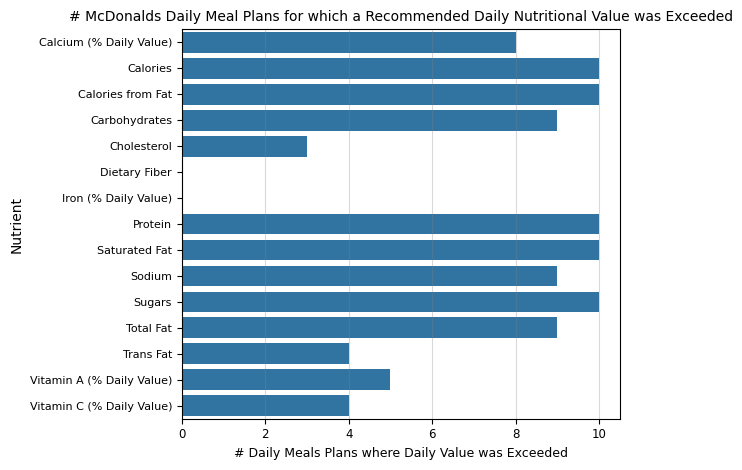

In [540]:
#Evaluate how many daily meal plans exceeded the recommended daily value for each nutrient
plot_all_meal_results = all_meal_results.groupby('Nutrient')['Daily Value Exceeded?'].sum().reset_index().rename(
                            columns={'Daily Value Exceeded?':'# Meal Plans where Daily Value was Exceeded'})

#visualize the data
ax1 = sns.barplot(data=plot_all_meal_results, y='Nutrient', x='# Meal Plans where Daily Value was Exceeded', 
                    color=sns.color_palette()[0])
#edit plot details
plt.title('# McDonalds Daily Meal Plans for which a Recommended Daily Nutritional Value was Exceeded', fontsize=10)
plt.xlabel(xlabel='# Daily Meals Plans where Daily Value was Exceeded', fontsize=9)
plt.xticks(fontsize=8.5)
plt.ylabel('Nutrient')
plt.yticks(fontsize=8)
plt.grid(axis='x',alpha=0.3,color='gray')
plt.tight_layout();

The plot above illustrates each nutrient in the McDonalds dataset & the number of times in which the daily recommended value--per the US FDA--was exceeded for each nutrient. This data was formed with 80 total food items from the McDonalds dataset, each of which were randomly sampled. Eight groups of items were collected to form one day's worth of food, or three meals worth, & so there were ten such daily meal plans in total that formed the data of this figure. More details on how these meals were constructed & assembled are available above. Moreover, the recommended daily values for each nutrient are available in the `FDA_daily_nutrients` variable. There are 15 unique nutrients. 
By compiling the results across a sizable number of random daily meals, it could provide an idea as to how proficient a typical day's worth of meals at McDonalds is at providing a healthy amount of daily nutrients.

Of the 15 nutrients, the daily recommended value is exceeded for 13 of them in at least three random daily meal plans. Moreover, nine of these nutrients's recommended daily values were exceeded in at least eight of the ten daily meal plans. The two nutrients whose daily values were never exceeded for any daily meal plan were dietary fiber & iron. Given this information, some conclusions can be made regarding a typical day's worth of McDonalds food items.
- McDonalds meals usually fail to provide enough dietary fiber & iron relative to recommended daily nutrients.
- McDonalds meals often provide excessive amounts of calcium, calories, calories from fat, carbohydrates, protein, saturated fat, sodium, added sugars, & total fat.
- McDonalds meals sometimes provide too much cholesterol, trans fat, vitamin A, & vitamin C.

Furthermore, recall that the US FDA also recommends eating foods that are:
- Higher in dietary fiber, calcium, & iron.
- Lower in saturated fat, sodium, & added sugars.

Of these six nutrients directly above, the data above indicates that a typical day's worth of McDonalds food only fulfills one of them--larger quantities of calcium. As such, it can be concluded that a typical day's worth of McDonalds meals does not provide adequate amounts of nutritional value, at least according to the recommendations laid out by the US FDA.

### Manually Constructed Meal Plan

Next, create a daily meal plan by hand such that the recommended daily nutritional values are not exceeded. This process was done manually & tinkered with until the recommended daily nutritional values were not exceeded.

In [541]:
#Find 8 food items across 3 meals
#BREAKFAST
breakf_items = ["Hotcakes", "Iced Coffee with Sugar Free French Vanilla Syrup (Medium)"]
#LUNCH
lunch_items = ["Diet Dr Pepper (Large)", "Filet-O-Fish", "Small French Fries"]
#DINNER
dinn_items = ["Hamburger", "Dasani Water Bottle", "Chocolate Chip Cookie"]

#collect all data for these items
daily_meal = orig_df[orig_df.Item.isin(breakf_items + lunch_items + dinn_items)]
#display(daily_meal)

In [545]:
#obtain the analysis for this constructed meal plan
meal_manual = analyze_random_meal(daily_meal)
meal_manual

,Nutrient,Current Daily Value,Meal Total,Daily Value Exceeded?
0,Calcium (% Daily Value),100.0,46.0,False
1,Calories,2000.0,1490.0,False
2,Calories from Fat,600.0,550.0,False
3,Carbohydrates,275.0,194.0,False
4,Cholesterol,300.0,125.0,False
5,Dietary Fiber,28.0,9.0,False
6,Iron (% Daily Value),100.0,52.0,False
7,Protein,50.0,44.0,False
8,Saturated Fat,20.0,18.5,False
9,Sodium,2300.0,2110.0,False


In [548]:
#Visualize the nutritional distributions of these food items
    #not all nutrients were included bc some had very small quantities in total or many had 0
fig = make_subplots(rows=5, cols=2, horizontal_spacing=0.07, vertical_spacing=0.04, 
                    specs=[[{'type':'domain'}, {'type':'domain'}], [{'type':'domain'}, {'type':'domain'}],
                          [{'type':'domain'}, {'type':'domain'}], [{'type':'domain'}, {'type':'domain'}],
                          [{'type':'domain'}, {'type':'domain'}]],
                   subplot_titles=['Calories','Total Fat','Cholesterol','Sodium','Carbohydrates','Dietary Fiber',
                                  'Sugars','Protein','Calcium (% Daily Value)','Iron (% Daily Value)'])
#CALORIES
fig1 = px.pie(daily_meal, values='Calories', names='Item')
#add plot to the subplot figure
fig.add_trace(fig1.data[0], row=1, col=1)

#TOTAL FAT
fig2 = px.pie(daily_meal, values='Total Fat', names='Item')
fig.add_trace(fig2.data[0], row=1, col=2)

#CHOLESTEROL
fig3 = px.pie(daily_meal, values='Cholesterol', names='Item')
fig.add_trace(fig3.data[0], row=2, col=1)

#SODIUM
fig4 = px.pie(daily_meal, values='Sodium', names='Item')
fig.add_trace(fig4.data[0], row=2, col=2)

#CARBOHYDRATES
fig5 = px.pie(daily_meal, values='Carbohydrates', names='Item')
fig.add_trace(fig5.data[0], row=3, col=1)

#DIETARY FIBER
fig6 = px.pie(daily_meal, values='Dietary Fiber', names='Item')
fig.add_trace(fig6.data[0], row=3, col=2)

#SUGARS
fig7 = px.pie(daily_meal, values='Sugars', names='Item')
fig.add_trace(fig7.data[0], row=4, col=1)

#PROTEIN
fig8 = px.pie(daily_meal, values='Protein', names='Item')
fig.add_trace(fig8.data[0], row=4, col=2)

#CALCIUM
fig9 = px.pie(daily_meal, values='Calcium (% Daily Value)', names='Item')
fig.add_trace(fig9.data[0], row=5, col=1)

#IRON
fig10 = px.pie(daily_meal, values='Iron (% Daily Value)', names='Item')
fig.add_trace(fig10.data[0], row=5, col=2)

#edit plot details
fig.update_layout(height=1800, width=1200, title_text="Nutritional Distributions of the Constructed Daily Meal", 
                 legend_title_text="Food Item")
fig.show()

The plots above display how much of each nutrient each of the eight items in the constructed daily meal plan account for. Of the 15 nutrients in the dataset, only ten were plotted here. In each of these pie charts, there was at least one item that accounted for zero percent of that nutrient's distribution across the entire daily meal plan.

The Filet-O-Fish accounts for the largest pie slice in the distributions of five of the ten nutrients--calories, total fat, cholesterol, protein, & calcium. Hotcakes accounts for most of three other nutrients. The Dasani Water Bottle item has no nutritional values across each of these ten nutrients. 
- For most of these nutrients, the Filet-O-Fish, Hotcakes, & Hamburger contribute the most nutritional value to this day's worth of food.
- For most of these nutrients, the Dasani Water Bottle & Diet Dr. Pepper (Large) contribute the least nutritional value to this day's worth of food.

### Sources

- [Dataset Source](https://www.kaggle.com/datasets/mcdonalds/nutrition-facts)
- [US FDA: Daily Nutrition](https://www.fda.gov/food/nutrition-facts-label/daily-value-nutrition-and-supplement-facts-labels)
- [McDonalds' website](https://www.mcdonalds.com/us/en-us.html)
- 